#### 1.0 Importação das Bibliotecas

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split


In [30]:
ch=pd.read_csv('data/train.csv',index_col='id')
print(ch.shape)
ch

(594194, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No


In [31]:

ch['Churn'].value_counts(normalize=True)

Churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64

### Como visto na distribuição da variavel target, se faz necessaria uma estratificação.


In [32]:

x_train,x_test,y_train,y_test=train_test_split(ch.drop('Churn',axis=1),ch['Churn'],test_size=0.2,random_state=42,stratify=ch['Churn'])
x_train.shape,x_test.shape,y_train.shape,y_test.shape


((475355, 19), (118839, 19), (475355,), (118839,))

In [33]:
print(x_train.info())
x_train.head()

<class 'pandas.core.frame.DataFrame'>
Index: 475355 entries, 6165 to 280641
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            475355 non-null  object 
 1   SeniorCitizen     475355 non-null  int64  
 2   Partner           475355 non-null  object 
 3   Dependents        475355 non-null  object 
 4   tenure            475355 non-null  int64  
 5   PhoneService      475355 non-null  object 
 6   MultipleLines     475355 non-null  object 
 7   InternetService   475355 non-null  object 
 8   OnlineSecurity    475355 non-null  object 
 9   OnlineBackup      475355 non-null  object 
 10  DeviceProtection  475355 non-null  object 
 11  TechSupport       475355 non-null  object 
 12  StreamingTV       475355 non-null  object 
 13  StreamingMovies   475355 non-null  object 
 14  Contract          475355 non-null  object 
 15  PaperlessBilling  475355 non-null  object 
 16  PaymentMethod     4753

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
id,,,,,,,,,,,,,,,,,,,
6165,Male,0,Yes,No,60,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,104.90,6273.40
565551,Female,1,No,No,47,Yes,Yes,DSL,No,Yes,No,No,Yes,Yes,One year,No,Electronic check,74.40,3847.75
85537,Female,0,No,Yes,11,Yes,No,DSL,No,No,No,Yes,No,Yes,Month-to-month,No,Bank transfer (automatic),59.45,669.45
137025,Female,0,Yes,Yes,35,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,One year,No,Bank transfer (automatic),62.25,2460.55
436494,Female,0,No,No,56,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.50,5149.45


### 2.0 Analise Descritiva

In [34]:
x_train.describe(include='object').T.sort_values('unique')

,count,unique,top,freq
gender,475355,2,Female,238927
Partner,475355,2,Yes,247799
Dependents,475355,2,No,331445
PhoneService,475355,2,Yes,446290
PaperlessBilling,475355,2,Yes,292581
MultipleLines,475355,3,No,226832
InternetService,475355,3,Fiber optic,218053
OnlineSecurity,475355,3,No,231550
OnlineBackup,475355,3,No,200138
DeviceProtection,475355,3,No,197863


In [35]:
x_train.describe(exclude='object').T.sort_values('mean')

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,475355.0,0.113963,0.317767,0.00,0.00,0.00,0.0,1.00
tenure,475355.0,36.574846,25.052064,1.00,12.00,35.00,62.0,72.00
MonthlyCharges,475355.0,65.892025,31.078944,18.25,29.90,74.15,90.8,118.75
TotalCharges,475355.0,2495.627796,2355.014539,18.80,639.95,1434.65,4264.0,8684.80


In [36]:
cat_vars=x_train.describe(include='object').columns
num_vars=x_train.describe(exclude='object').columns

In [37]:
x_train[num_vars].corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,-0.084576,0.228981,0.042812
tenure,-0.084576,1.000000,0.125093,0.769911
MonthlyCharges,0.228981,0.125093,1.000000,0.634832
TotalCharges,0.042812,0.769911,0.634832,1.000000


In [38]:
cat_vars

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

C:\Users\Gabri\AppData\Local\Temp\ipykernel_8736\186748201.py:7: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


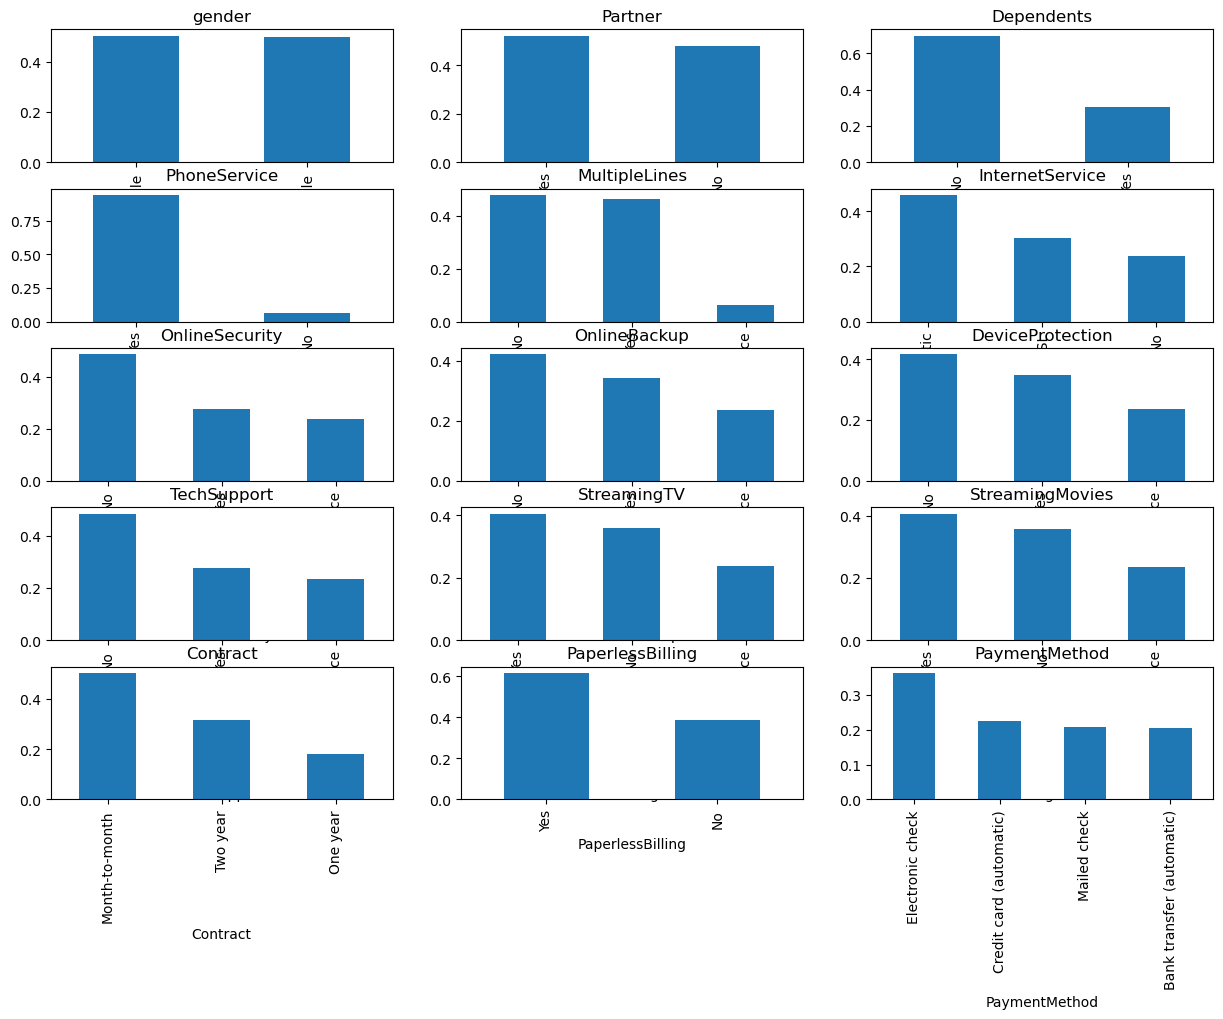

In [46]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    x_train[col].value_counts(normalize=True).plot(kind='bar', ax=axes[i], title=col)

plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>],
       [<Axes: title={'center': 'MonthlyCharges'}>,
        <Axes: title={'center': 'TotalCharges'}>]], dtype=object)

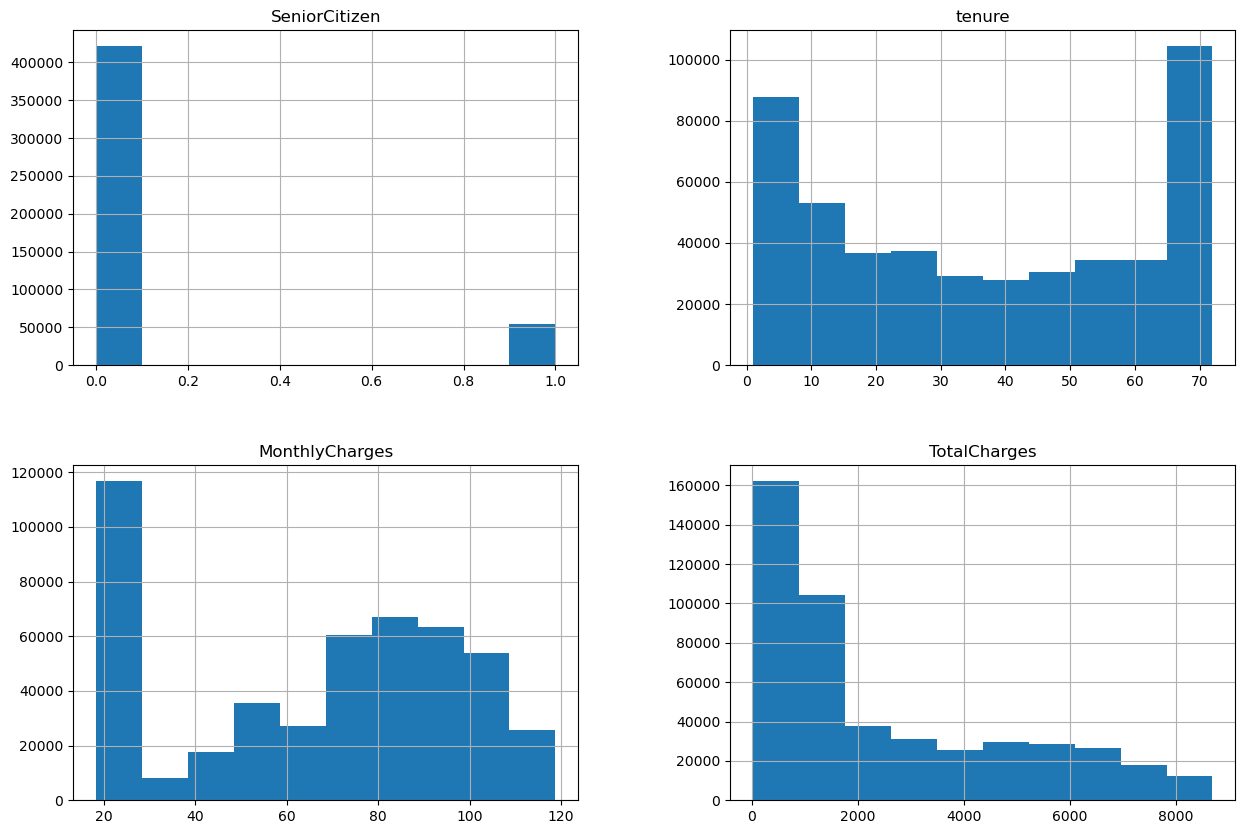

In [23]:
x_train[num_vars].hist(figsize=(15,10))